# 10. 演習の解答

01–09 章の演習 40 問の解答。問題文を 1 行で再掲したうえで、
導出を求めるものには式変形を、測定を求めるものには実行できるコードを置いた。

| 章 | 問題数 | 章 | 問題数 |
|---|---:|---|---:|
| 01 波・複素数・内積 | 4 | 06 DFT/FFT・標本化 | 4 |
| 02 フーリエ級数 | 4 | 07 時間周波数解析 | 5 |
| 03 収束・エネルギー | 4 | 08 PDE とスペクトル法 | 4 |
| 04 フーリエ変換 | 5 | 09 応用 | 5 |
| 05 畳み込みとフィルタ | 5 | | |

In [1]:
# Shared setup: make fourier_book importable, fix seeds, inline rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import fourier_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "fourier_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import matplotlib.pyplot as plt
import numpy as np

from fourier_book import datasets, filters, plotting, signals, spectral, transforms, widgets

np.set_printoptions(precision=3, suppress=True)

## 01 章 — 波・複素数・内積

### 01-1 位相と余弦

> $\sin(\theta+\pi/2)=\cos\theta$ を Euler の公式から示せ。

$\sin\phi = \frac{e^{i\phi}-e^{-i\phi}}{2i}$ に $\phi=\theta+\pi/2$ を入れる。
$e^{\pm i\pi/2} = \pm i$ なので

$$
\sin(\theta+\tfrac{\pi}{2})
= \frac{i e^{i\theta} - (-i) e^{-i\theta}}{2i}
= \frac{e^{i\theta} + e^{-i\theta}}{2} = \cos\theta
$$

位相を $\pi/2$ 進めることは、複素平面で $i$ を掛けること(90 度回転)に等しい。

In [2]:
th = np.linspace(0, 4 * np.pi, 2001)
print(f"max |sin(θ+π/2) - cos θ| = {np.max(np.abs(np.sin(th + np.pi / 2) - np.cos(th))):.2e}")

max |sin(θ+π/2) - cos θ| = 9.51e-16


### 01-2 直交の破れ

> Gram 行列を $[0, 2.3)$ で作ると単位行列からどれだけずれるか。

直交性は「周期の整数倍で積分する」ことに依存している。
$2.3$ は $2\pi$ の整数倍でないので、内積に **端数の寄与** が残る。

In [3]:
def gram(upper, n_max=5, n_pts=20001):
    tt = np.linspace(0, upper, n_pts, endpoint=False)
    basis = np.array([np.exp(1j * k * tt) for k in range(1, n_max + 1)])
    return (basis @ basis.conj().T) * (tt[1] - tt[0]) / upper

for upper, label in [(2 * np.pi, "[0, 2π)  整数周期"), (2.3, "[0, 2.3)  端数あり")]:
    G = gram(upper)
    off = np.max(np.abs(G - np.eye(G.shape[0])))
    print(f"{label:22s}  max |G - I| = {off:.3e}")

[0, 2π)  整数周期           max |G - I| = 2.220e-16
[0, 2.3)  端数あり          max |G - I| = 7.937e-01


### 01-3 平均パワー

> $A\sin(2\pi f t)$ の 1 周期平均パワーが $A^2/2$ になることを確かめよ。

$$
\frac{1}{T}\int_0^T A^2\sin^2(2\pi f t)\,dt
= \frac{A^2}{T}\int_0^T \frac{1-\cos(4\pi f t)}{2}dt = \frac{A^2}{2}
$$

第 2 項は 1 周期の整数倍で積分すると消える。実効値が $A/\sqrt{2}$ になる根拠でもある。

In [4]:
for A, f in [(1.0, 3.0), (2.5, 7.0)]:
    tt = np.linspace(0, 1 / f, 100001)
    print(f"A = {A}, f = {f}:  measured {np.mean((A * np.sin(2 * np.pi * f * tt)) ** 2):.6f}"
          f"   A²/2 = {A**2 / 2:.6f}")

A = 1.0, f = 3.0:  measured 0.499995   A²/2 = 0.500000
A = 2.5, f = 7.0:  measured 3.124969   A²/2 = 3.125000


### 01-4 射影(のこぎり波)

> $f(x)=x$ の $b_n$ を数値計算し $2(-1)^{n+1}/n$ と比べよ。

$$
b_n = \frac{1}{\pi}\int_{-\pi}^{\pi} x \sin(nx)\,dx
= \frac{2}{\pi}\int_0^{\pi} x\sin(nx)\,dx
$$

部分積分して $\int_0^\pi x\sin(nx)dx = \frac{\pi(-1)^{n+1}}{n}$ なので $b_n = 2(-1)^{n+1}/n$。
$1/n$ の減衰は、$x$ を周期 $2\pi$ で延長したときに端点で **跳びが生じる** ことの帰結である。

In [5]:
a, b = transforms.trig_coeffs(lambda z: z, n_max=8, period=2 * np.pi)
print(f"{'n':>3} {'numeric b_n':>13} {'2(-1)^(n+1)/n':>16}")
for n in range(1, 9):
    print(f"{n:3d} {b[n - 1]:13.6f} {2 * (-1) ** (n + 1) / n:16.6f}")

  n   numeric b_n    2(-1)^(n+1)/n
  1      0.000000         2.000000
  2     -2.000000        -1.000000
  3     -0.999999         0.666667
  4     -0.666665        -0.500000
  5     -0.499998         0.400000
  6     -0.399998        -0.333333
  7     -0.333331         0.285714
  8     -0.285712        -0.250000


## 02 章 — フーリエ級数

### 02-1 のこぎり波の係数

01-4 と同じ。`trig_coeffs` の出力が $2(-1)^{n+1}/n$ に一致する。
上のセルで確認済みなので繰り返さない。

### 02-2 三角波の滑らかさ

> 三角波の係数が $1/n^2$ で減衰することを log-log で確かめ、矩形波($1/n$)と比べよ。

減衰の速さは滑らかさで決まる。関数が $C^{k}$ で $k+1$ 階微分に跳びがあるとき、
係数は $|c_n| \sim n^{-(k+2)}$ で減る。矩形波は関数自体に跳びがあるので $1/n$、
三角波は連続だが微分に跳びがあるので $1/n^2$ になる。

   square: measured slope  -0.75   expected -1
 triangle: measured slope  -2.00   expected -2


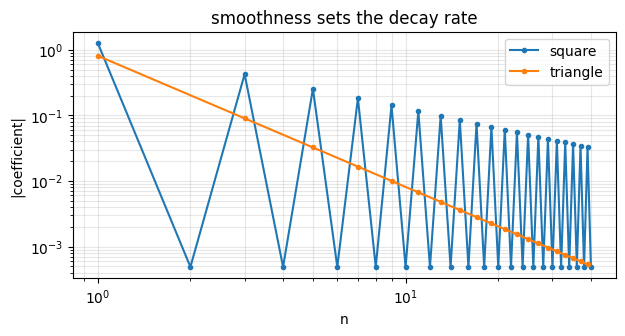

In [6]:
tt = np.linspace(-np.pi, np.pi, 8192, endpoint=False)
for name, fn, expect in [("square", lambda z: signals.square_wave(z, 1 / (2 * np.pi)), 1),
                         ("triangle", lambda z: signals.triangle_wave(z, 1 / (2 * np.pi)), 2)]:
    a_, b_ = transforms.trig_coeffs(fn, n_max=40, period=2 * np.pi)
    mag = np.hypot(a_[1:], b_[1:])
    ns = np.arange(1, mag.size + 1)
    keep = mag > 1e-9
    slope = np.polyfit(np.log(ns[keep]), np.log(mag[keep]), 1)[0]
    print(f"{name:>9}: measured slope {slope:6.2f}   expected {-expect}")

fig, ax = plt.subplots(figsize=(7, 3.2))
for name, fn in [("square", lambda z: signals.square_wave(z, 1 / (2 * np.pi))),
                 ("triangle", lambda z: signals.triangle_wave(z, 1 / (2 * np.pi)))]:
    a_, b_ = transforms.trig_coeffs(fn, n_max=40, period=2 * np.pi)
    mag = np.hypot(a_[1:], b_[1:])
    ns = np.arange(1, mag.size + 1)
    keep = mag > 1e-9
    ax.loglog(ns[keep], mag[keep], "o-", ms=3, label=name)
ax.set_xlabel("n"); ax.set_ylabel("|coefficient|"); ax.legend(); ax.grid(alpha=0.3, which="both")
ax.set_title("smoothness sets the decay rate")
plt.show()

### 02-3 偶奇分解

> 偶部が余弦のみ、奇部が正弦のみで表せることを示せ。

$f_e(x)=\frac{f(x)+f(-x)}{2}$ は偶関数で、$\int f_e(x)\sin(nx)dx$ は
奇関数の対称区間積分なので 0。よって $b_n=0$。奇部も同様に $a_n=0$。

In [7]:
rng_e = np.random.default_rng(0)
coef = rng_e.normal(size=6)
f_any = lambda z: sum(c * np.sin((k + 1) * z + 0.7 * k) for k, c in enumerate(coef))
f_even = lambda z: 0.5 * (f_any(z) + f_any(-z))
f_odd = lambda z: 0.5 * (f_any(z) - f_any(-z))

for name, fn in [("even part", f_even), ("odd part", f_odd)]:
    a_, b_ = transforms.trig_coeffs(fn, n_max=8, period=2 * np.pi)
    print(f"{name:>10}:  max|a_n| = {np.max(np.abs(a_)):.2e}   max|b_n| = {np.max(np.abs(b_)):.2e}")

 even part:  max|a_n| = 6.31e-01   max|b_n| = 2.26e-16
  odd part:  max|a_n| = 1.11e-16   max|b_n| = 5.05e-01


### 02-4 Gibbs のオーバーシュート

> 倍音数 $N$ を変えても overshoot 比が一定に近づくことを示せ。

跳びの大きさに対する行き過ぎの比は $N\to\infty$ で

$$
\frac{1}{\pi}\int_0^\pi \frac{\sin u}{u}du - \frac{1}{2} \approx 0.0895
$$

に収束する。**振動の幅は縮むが高さは縮まない**。有限個の滑らかな関数で
不連続を表そうとする限り消えない、原理的な現象である。

In [8]:
tt = np.linspace(-np.pi, np.pi, 20001)
print(f"{'N':>5} {'overshoot ratio':>18}")
for N in [5, 11, 25, 51, 101, 201]:
    partial = signals.square_wave_partial_sum(tt, 1 / (2 * np.pi), N)
    print(f"{N:5d} {(partial.max() - 1.0) / 2.0:18.5f}")
print(f"{'limit':>5} {0.0894898722:18.5f}")

    N    overshoot ratio
    5            0.09116
   11            0.08983


   25            0.08956


   51            0.08951


  101            0.08944
  201            0.08948
limit            0.08949


## 03 章 — 収束・エネルギー・Parseval

### 03-1 Basel 型の和

> 矩形波の Parseval から $\sum_{n\ \text{odd}} 1/n^2 = \pi^2/8$ を導け。

振幅 1 の矩形波は $f(x)=\frac{4}{\pi}\sum_{n\ \text{odd}} \frac{\sin nx}{n}$。
Parseval は $\frac{1}{\pi}\int_{-\pi}^{\pi}|f|^2 dx = \sum_n (a_n^2+b_n^2)$ で、
左辺は $2$、右辺は $\sum_{n\ \text{odd}} \left(\frac{4}{\pi n}\right)^2$。したがって

$$
2 = \frac{16}{\pi^2}\sum_{n\ \text{odd}} \frac{1}{n^2}
\;\Longrightarrow\;
\sum_{n\ \text{odd}} \frac{1}{n^2} = \frac{\pi^2}{8}
$$

In [9]:
odd = np.arange(1, 200001, 2)
print(f"partial sum       = {np.sum(1 / odd.astype(float) ** 2):.10f}")
print(f"π²/8              = {np.pi**2 / 8:.10f}")

partial sum       = 1.2336980501
π²/8              = 1.2337005501


### 03-2 三角波の Parseval

> 三角波で Parseval を数値確認し、累積エネルギー図を描け。

(1/π)∫|f|²  = 0.666667
Σ (aₙ²+bₙ²) = 0.666666   (60 harmonics)


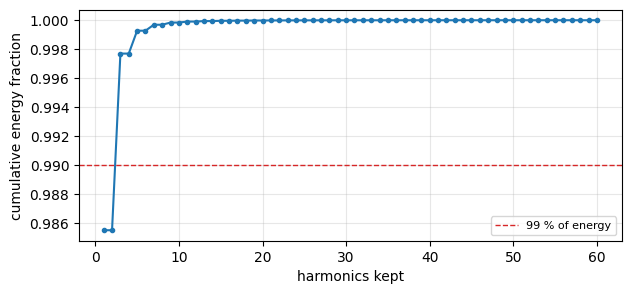

99 % のエネルギーに必要な倍音数: 3


In [10]:
tt = np.linspace(-np.pi, np.pi, 16384, endpoint=False)
tri = signals.triangle_wave(tt, 1 / (2 * np.pi))
a_, b_ = transforms.trig_coeffs(lambda z: signals.triangle_wave(z, 1 / (2 * np.pi)),
                                n_max=60, period=2 * np.pi)
lhs = np.mean(tri**2) * 2
rhs = a_[0] ** 2 / 2 * 2 + np.sum(a_[1:] ** 2 + b_[1:] ** 2)
print(f"(1/π)∫|f|²  = {lhs:.6f}")
print(f"Σ (aₙ²+bₙ²) = {rhs:.6f}   (60 harmonics)")

cum = np.cumsum(a_[1:] ** 2 + b_[1:] ** 2) / rhs
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(np.arange(1, cum.size + 1), cum, "o-", ms=3)
ax.axhline(0.99, color="#d62728", ls="--", lw=1, label="99 % of energy")
ax.set_xlabel("harmonics kept"); ax.set_ylabel("cumulative energy fraction")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()
print(f"99 % のエネルギーに必要な倍音数: {int(np.argmax(cum >= 0.99)) + 1}")

### 03-3 MSE は小さいが max error は大きい例

> そのような例を作って図で示せ。

矩形波の部分和がまさにこれである。Gibbs の耳が跳びの近傍に残るので
$\|f - S_N\|_\infty$ は 0 に行かない。一方エネルギー(2 乗)で測ると、
耳の幅が $O(1/N)$ で縮むので $\|f-S_N\|_2 \to 0$ になる。
**収束は測り方で結論が変わる。**

In [11]:
tt = np.linspace(-np.pi, np.pi, 20001)
target = signals.square_wave(tt, 1 / (2 * np.pi))
print(f"{'N':>5} {'L2 error':>12} {'max error':>12}")
for N in [5, 21, 81, 321]:
    partial = signals.square_wave_partial_sum(tt, 1 / (2 * np.pi), N)
    l2 = float(np.sqrt(np.mean((partial - target) ** 2)))
    print(f"{N:5d} {l2:12.5f} {float(np.max(np.abs(partial - target))):12.5f}")
print("\nL2 は 0 に落ちるが max は落ちない")

    N     L2 error    max error
    5      0.20098      1.00000
   21      0.09822      1.00000
   81      0.05003      1.00000
  321      0.02521      1.00000

L2 は 0 に落ちるが max は落ちない


### 03-4 $|\sin x|$ の係数減衰

> 減衰の次数を測り、滑らかさと整合するか調べよ。

$|\sin x|$ は連続だが $x=0,\pi$ で微分に跳びがある($C^0$)。
予測される減衰は $1/n^2$。実際、$|\sin x|$ は周期 $\pi$ を持つので
偶数次の余弦係数だけが残り $a_{2k} = -\frac{4}{\pi(4k^2-1)} \sim k^{-2}$ になる。

In [12]:
a_, b_ = transforms.trig_coeffs(lambda z: np.abs(np.sin(z)), n_max=40, period=2 * np.pi)
mag = np.hypot(a_[1:], b_[1:])
ns = np.arange(1, mag.size + 1)
keep = mag > 1e-8
slope = np.polyfit(np.log(ns[keep]), np.log(mag[keep]), 1)[0]
print(f"measured decay slope = {slope:.2f}  (expected -2 for a C⁰ function)")
print(f"{'k':>3} {'a_2k numeric':>14} {'-4/(π(4k²-1))':>16}")
for k in range(1, 6):
    print(f"{k:3d} {a_[2 * k]:14.6f} {-4 / (np.pi * (4 * k**2 - 1)):16.6f}")

measured decay slope = -2.06  (expected -2 for a C⁰ function)
  k   a_2k numeric    -4/(π(4k²-1))
  1      -0.424413        -0.424413
  2      -0.084883        -0.084883
  3      -0.036379        -0.036378
  4      -0.020210        -0.020210
  5      -0.012861        -0.012861


## 04 章 — フーリエ変換

### 04-1 不確定性

> $e^{-\pi a x^2}$ の時間幅と周波数幅の積が $a$ によらないことを確かめよ。

ガウス関数 $e^{-\pi a x^2}$ の変換は $a^{-1/2}e^{-\pi\xi^2/a}$。
密度として正規化した標準偏差は $\sigma_x = \frac{1}{2\sqrt{\pi a}}$、
$\sigma_\xi = \frac{\sqrt a}{2\sqrt\pi}$ なので

$$
\sigma_x \sigma_\xi = \frac{1}{4\pi}
$$

$a$ が消える。これは不確定性原理 $\sigma_x\sigma_\xi \ge \frac{1}{4\pi}$ の
**等号が成り立つ唯一の関数** がガウス関数であることの現れである。

In [13]:
xg = np.linspace(-12, 12, 8192)
def spread(grid, dens):
    w = np.abs(dens) ** 2
    w = w / np.trapezoid(w, grid)
    mu = np.trapezoid(grid * w, grid)
    return float(np.sqrt(np.trapezoid((grid - mu) ** 2 * w, grid)))

print(f"{'a':>6} {'σ_x':>10} {'σ_ξ':>10} {'product':>10} {'1/(4π)':>10}")
for a_val in [0.25, 1.0, 4.0]:
    fx = np.exp(-np.pi * a_val * xg**2)
    dt_ = xg[1] - xg[0]
    Fx = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(fx))) * dt_
    xi_ = np.fft.fftshift(np.fft.fftfreq(xg.size, d=dt_))
    sx, sxi = spread(xg, fx), spread(xi_, Fx)
    print(f"{a_val:6.2f} {sx:10.5f} {sxi:10.5f} {sx * sxi:10.6f} {1 / (4 * np.pi):10.6f}")

     a        σ_x        σ_ξ    product     1/(4π)
  0.25    0.56419    0.14105   0.079577   0.079577
  1.00    0.28209    0.28209   0.079577   0.079577
  4.00    0.14105    0.56419   0.079577   0.079577


### 04-2 矩形と sinc

> $\mathrm{rect}$ の変換が sinc になることを示し、裾が $1/\xi$ でしか減らない理由を述べよ。

$$
\int_{-1/2}^{1/2} e^{-2\pi i x\xi} dx
= \frac{\sin(\pi\xi)}{\pi\xi} = \mathrm{sinc}(\xi)
$$

裾の減衰は 03 章と同じ論理である。$\mathrm{rect}$ は **関数自体に跳び** があるので、
変換の減衰は $1/\xi$ にしかならない。滑らかさと減衰は変換の両側で対になっている。

In [14]:
xg = np.linspace(-16, 16, 16384)
rect = (np.abs(xg) <= 0.5).astype(float)
dt_ = xg[1] - xg[0]
R = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rect))) * dt_
xi_ = np.fft.fftshift(np.fft.fftfreq(xg.size, d=dt_))
sinc = np.sinc(xi_)
band = np.abs(xi_) < 12
print(f"max |numeric - sinc| on |ξ|<12 = {np.max(np.abs(R[band].real - sinc[band])):.2e}")
peaks = np.abs(xi_[(np.abs(xi_) > 1) & (np.abs(xi_) < 40)])
print("envelope check: |sinc(ξ)| * |ξ| stays O(1) ->",
      f"{np.max(np.abs(np.sinc(peaks)) * peaks):.4f}")

max |numeric - sinc| on |ξ|<12 = 7.70e-05
envelope check: |sinc(ξ)| * |ξ| stays O(1) -> 0.3183


### 04-3 微分は高周波を増幅する

> $f'' \leftrightarrow -(2\pi\xi)^2\hat f$ を確かめ、微分がノイズに弱い理由を述べよ。

微分は周波数に $2\pi i\xi$ を掛ける。$n$ 階なら $(2\pi i \xi)^n$ で、
**高周波ほど強く増幅される**。信号のノイズは典型的に広帯域なので、
微分すると高周波のノイズだけが持ち上がり SN 比が落ちる。
実務で微分の前に平滑化を入れるのはこのためである。

In [15]:
xg = np.linspace(-8, 8, 4096)
dt_ = xg[1] - xg[0]
g = np.exp(-np.pi * xg**2)
G = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(g))) * dt_
xi_ = np.fft.fftshift(np.fft.fftfreq(xg.size, d=dt_))
d2 = np.gradient(np.gradient(g, dt_), dt_)
D2 = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(d2))) * dt_
print(f"max rel.err of f'' <-> -(2πξ)² fhat : "
      f"{np.max(np.abs(D2 - (-(2 * np.pi * xi_) ** 2) * G)) / np.max(np.abs(D2)):.2e}")

rng_d = np.random.default_rng(0)
noisy = g + 0.01 * rng_d.normal(size=g.size)
print(f"\nSNR of signal            : {np.std(g) / 0.01:8.1f}")
print(f"SNR after one derivative : "
      f"{np.std(np.gradient(g, dt_)) / np.std(np.gradient(noisy - g, dt_)):8.1f}")

max rel.err of f'' <-> -(2πξ)² fhat : 9.40e-05

SNR of signal            :     20.1
SNR after one derivative :      0.2


### 04-4 復調

> $g(x)\cos(2\pi f_0x)$ から $g$ を取り出せ。

もう一度 $\cos(2\pi f_0 x)$ を掛けると

$$
g\cos^2(2\pi f_0 x) = \frac{g}{2} + \frac{g}{2}\cos(4\pi f_0 x)
$$

第 1 項がベースバンド、第 2 項が $2f_0$ 付近。ローパスで第 2 項を落とし、2 倍すれば $g$ に戻る。

max |demodulated - g| = 0.0000   (peak of g = 1.2061)


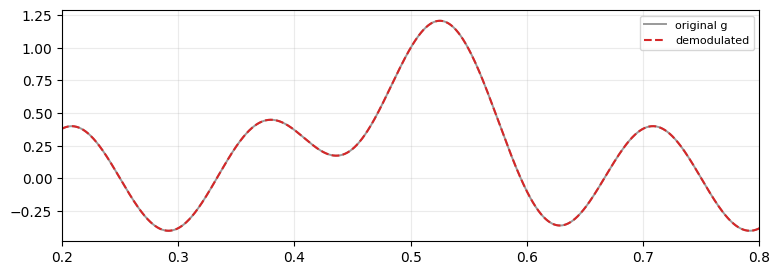

In [16]:
fs_dm = 2000.0
t_dm = np.arange(0, 1.0, 1 / fs_dm)
g_base = signals.gaussian_pulse(t_dm, t0=0.5, width=0.05) + 0.4 * signals.sine(t_dm, 6.0)
f0_dm = 200.0
modulated = g_base * np.cos(2 * np.pi * f0_dm * t_dm)
demod = filters.lowpass(modulated * np.cos(2 * np.pi * f0_dm * t_dm), fs_dm, 60.0) * 2
print(f"max |demodulated - g| = {np.max(np.abs(demod - g_base)):.4f}"
      f"   (peak of g = {np.max(np.abs(g_base)):.4f})")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t_dm, g_base, color="#999", lw=1.4, label="original g")
ax.plot(t_dm, demod, "--", color="#d62728", label="demodulated")
ax.set_xlim(0.2, 0.8); ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.show()

### 04-5 rect で Plancherel の誤差が大きい理由

グリッドが有限なので、$\mathrm{rect}$ の変換 sinc は **打ち切られる**。
sinc の裾は $1/\xi$ でしか減らないため、切り捨てたエネルギーが無視できない。
ガウス関数は両側とも急速に減衰するので、同じグリッドでも誤差が桁違いに小さい。

さらに、不連続点をグリッド上でどう表現するかにも依存する
(端点の値を 1 にするか 1/2 にするかで $O(dx)$ の差が出る)。

In [17]:
print(f"{'grid points':>12} {'gaussian rel.err':>18} {'rect rel.err':>14}")
for n_pts in [1024, 4096, 16384]:
    xg = np.linspace(-8, 8, n_pts)
    dt_ = xg[1] - xg[0]
    for label, fx in [("g", np.exp(-np.pi * xg**2)), ("r", (np.abs(xg) <= 0.5).astype(float))]:
        F = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(fx))) * dt_
        xi_ = np.fft.fftshift(np.fft.fftfreq(n_pts, d=dt_))
        e_t = np.sum(np.abs(fx) ** 2) * dt_
        e_f = np.sum(np.abs(F) ** 2) * (xi_[1] - xi_[0])
        if label == "g":
            eg = abs(e_t - e_f) / e_t
        else:
            er = abs(e_t - e_f) / e_t
    print(f"{n_pts:12d} {eg:18.2e} {er:14.2e}")

 grid points   gaussian rel.err   rect rel.err
        1024           9.42e-16       6.65e-16


        4096           3.45e-15       3.55e-15
       16384           2.27e-13       2.27e-13


## 05 章 — 畳み込みとフィルタ

### 05-1 交換則

> $f*g = g*f$ を確かめ、畳み込み定理から見ると自明である理由を述べよ。

畳み込み定理は $\widehat{f*g} = \hat f\,\hat g$。右辺は複素数の掛け算なので可換である。
変換が単射(逆変換が存在する)ことから、時間側でも $f*g=g*f$ が従う。
定義の積分で変数変換 $u \to x-u$ をしても示せるが、周波数側なら 1 行で済む。

In [18]:
rng_c = np.random.default_rng(0)
f_c, g_c = rng_c.normal(size=64), rng_c.normal(size=40)
print(f"max |f*g - g*f| = {np.max(np.abs(np.convolve(f_c, g_c) - np.convolve(g_c, f_c))):.2e}")
n_pad = f_c.size + g_c.size - 1
prod = np.fft.rfft(f_c, n_pad) * np.fft.rfft(g_c, n_pad)
print(f"max |conv - IFFT(F·G)| = "
      f"{np.max(np.abs(np.convolve(f_c, g_c) - np.fft.irfft(prod, n_pad))):.2e}")

max |f*g - g*f| = 0.00e+00
max |conv - IFFT(F·G)| = 6.22e-15


### 05-2 移動平均の周波数応答

> 応答が $\frac{\sin(\pi k\xi)}{k\sin(\pi\xi)}$ になり、零点が $\xi=m/k$ に来ることを示せ。

長さ $k$ の移動平均は $h[n]=1/k$($0\le n<k$)。その DTFT は等比級数の和で

$$
H(\xi) = \frac{1}{k}\sum_{n=0}^{k-1} e^{-2\pi i n\xi}
= \frac{1}{k}\,\frac{1-e^{-2\pi i k\xi}}{1-e^{-2\pi i \xi}}
$$

絶対値を取ると $\left|\frac{\sin(\pi k\xi)}{k\sin(\pi\xi)}\right|$。
分子が 0 になるのは $k\xi$ が整数のとき、つまり $\xi=m/k$。
ただし $m$ が $k$ の倍数のときは分母も 0 になり、そこは通過域(利得 1)である。

zeros predicted at ξ = m/k: [0.125, 0.25, 0.375, 0.5]
zeros measured           : [0.125, 0.25, 0.375]


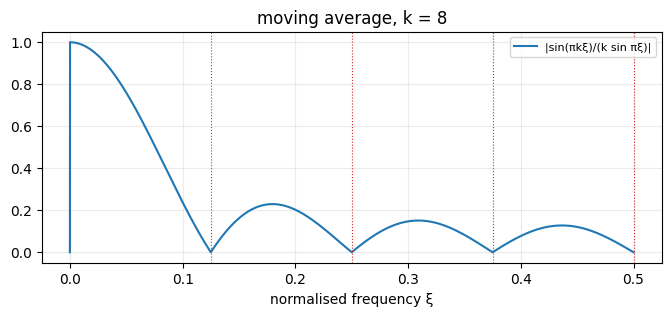

In [19]:
k = 8
xi_d = np.linspace(0, 0.5, 4001)
H = np.abs(np.sin(np.pi * k * xi_d) / (k * np.sin(np.pi * xi_d) + 1e-300))
h = np.ones(k) / k
H_num = np.abs(np.fft.rfft(h, 8000))[: xi_d.size]
xi_num = np.fft.rfftfreq(8000)[: xi_d.size]
print(f"zeros predicted at ξ = m/k: {[round(m / k, 4) for m in range(1, k // 2 + 1)]}")
dips = xi_num[1:-1][(H_num[1:-1] < H_num[:-2]) & (H_num[1:-1] < H_num[2:])]
print(f"zeros measured           : {[round(float(v), 4) for v in dips[:4]]}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(xi_d, H, label="|sin(πkξ)/(k sin πξ)|")
for m in range(1, k // 2 + 1):
    ax.axvline(m / k, color="#d62728", ls=":", lw=0.8)
ax.set_xlabel("normalised frequency ξ"); ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax.set_title(f"moving average, k = {k}")
plt.show()

### 05-3 ガウス同士の畳み込み

> 熱方程式の Green 関数で初期条件をガウスにし、結果が再びガウスになることを示せ。

分散が足し算になる。$N(0,\sigma_1^2) * N(0,\sigma_2^2) = N(0,\sigma_1^2+\sigma_2^2)$。
熱方程式では $\sigma^2_{\text{kernel}} = 2\alpha t$ なので、
初期幅 $\sigma_0$ のガウスは時刻 $t$ で $\sqrt{\sigma_0^2 + 2\alpha t}$ に広がる。

In [20]:
L_h, n_h, alpha_h = 40.0, 2048, 0.5
xh = np.linspace(-L_h / 2, L_h / 2, n_h, endpoint=False)
dxh = xh[1] - xh[0]
sigma0 = 0.8
u0_h = np.exp(-xh**2 / (2 * sigma0**2)) / (sigma0 * np.sqrt(2 * np.pi))
print(f"{'t':>6} {'measured σ':>12} {'sqrt(σ0²+2αt)':>16}")
for t_h in [0.5, 2.0, 8.0]:
    green_h = np.exp(-xh**2 / (4 * alpha_h * t_h)) / np.sqrt(4 * np.pi * alpha_h * t_h)
    u_h = np.fft.ifft(np.fft.fft(u0_h) * np.fft.fft(np.fft.ifftshift(green_h))).real * dxh
    w = u_h / np.trapezoid(u_h, xh)
    sig = float(np.sqrt(np.trapezoid(xh**2 * w, xh)))
    print(f"{t_h:6.1f} {sig:12.5f} {np.sqrt(sigma0**2 + 2 * alpha_h * t_h):16.5f}")

     t   measured σ    sqrt(σ0²+2αt)


   0.5      1.06771          1.06771
   2.0      1.62481          1.62481
   8.0      2.93939          2.93939


### 05-4 因果的フィルタと位相遅れ

> 片側の指数移動平均を実装し、位相遅れが出ることを示せ。

両側フィルタ(対称なカーネル)は周波数応答が実数なので位相を回さない。
その代わり **未来の値を使う**。因果的フィルタは過去だけを使うので実装できるが、
応答が複素数になり、周波数ごとに位相が遅れる。

バックテストで両側フィルタを使うと未来情報が漏れる(look-ahead bias)。
09 章で触れた注意点の実体がこれである。

causal EMA   lag =   32.0 ms
two-sided    lag =    0.0 ms  (uses the future)


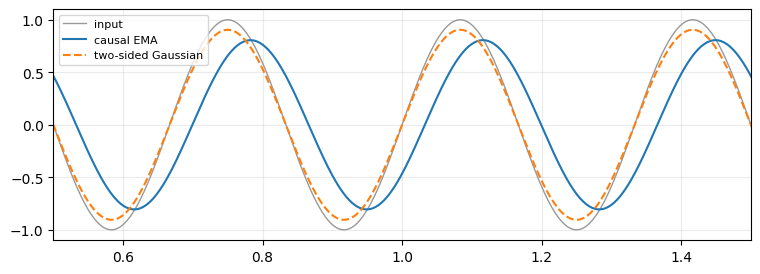

In [21]:
fs_p = 500.0
t_p = np.arange(0, 2.0, 1 / fs_p)
x_p = signals.sine(t_p, 3.0)

def ema(x, alpha):
    out = np.empty_like(x)
    out[0] = x[0]
    for i in range(1, x.size):
        out[i] = alpha * x[i] + (1 - alpha) * out[i - 1]
    return out

y_causal = ema(x_p, 0.05)
y_two_sided = filters.smooth_gaussian(x_p, sigma=12.0)
lag = int(np.argmax(np.correlate(x_p, y_causal, mode="full")) - (x_p.size - 1))
print(f"causal EMA   lag = {abs(lag) / fs_p * 1000:6.1f} ms")
lag2 = int(np.argmax(np.correlate(x_p, y_two_sided, mode="full")) - (x_p.size - 1))
print(f"two-sided    lag = {abs(lag2) / fs_p * 1000:6.1f} ms  (uses the future)")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t_p, x_p, color="#999", lw=1, label="input")
ax.plot(t_p, y_causal, label="causal EMA")
ax.plot(t_p, y_two_sided, "--", label="two-sided Gaussian")
ax.set_xlim(0.5, 1.5); ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.show()

### 05-5 遷移帯とリンギング

> 遷移帯の幅を変えてオーバーシュートを測れ。

遷移帯が広いほど、時間側のインパルス応答が短くなり、リンギングが減る。
極限で遷移帯 0(理想フィルタ)は sinc になり、Gibbs の 8.95% が残る。

In [22]:
fs_r2 = 1000.0
t_r2 = np.arange(0, 1.0, 1 / fs_r2)
step2 = (t_r2 > 0.5).astype(float)
fr2 = np.fft.rfftfreq(t_r2.size, d=1 / fs_r2)
spec2 = np.fft.rfft(step2)
cut = 40.0
print(f"{'transition width':>18} {'overshoot %':>13}")
for width in [1e-6, 5.0, 20.0, 60.0, 150.0]:
    mask = 0.5 * (1 - np.tanh((fr2 - cut) / max(width, 1e-6)))
    y = np.fft.irfft(spec2 * mask, n=t_r2.size)
    print(f"{width:18.1f} {(y.max() - 1.0) * 100:13.2f}")
print("\n遷移帯を広げるとリンギングが単調に減る")

  transition width   overshoot %
               0.0          8.99
               5.0          8.34
              20.0          0.32
              60.0        -21.04
             150.0        -37.07

遷移帯を広げるとリンギングが単調に減る


## 06 章 — DFT・FFT・標本化

### 06-1 ビンの周波数刻み

> $f_s=1000$、$N=250$ のときの刻みは何 Hz か。

$\Delta f = f_s / N = 1000/250 = 4$ Hz。分解能は **観測時間の逆数** でもある
($N/f_s = 0.25$ s なので $1/0.25 = 4$ Hz)。同じことを 2 通りに言っているだけである。

In [23]:
fs_b, N_b = 1000.0, 250
fr = transforms.fft_freqs(N_b, fs_b)
print(f"Δf = fs/N = {fs_b / N_b} Hz   measured spacing = {fr[1] - fr[0]} Hz")
print(f"observation time = N/fs = {N_b / fs_b} s   -> 1/T = {fs_b / N_b} Hz")

Δf = fs/N = 4.0 Hz   measured spacing = 4.0 Hz
observation time = N/fs = 0.25 s   -> 1/T = 4.0 Hz


### 06-2 折り返し

> $f_s=100$ Hz で 70 Hz の波はどこに alias するか。

Nyquist は 50 Hz。$70 > 50$ なので折り返して $|100 - 70| = 30$ Hz に現れる。
一般に $f_{\text{alias}} = |f - f_s \cdot \mathrm{round}(f/f_s)|$。

peak at 30.0 Hz  (input was 70 Hz, fs = 100 Hz)


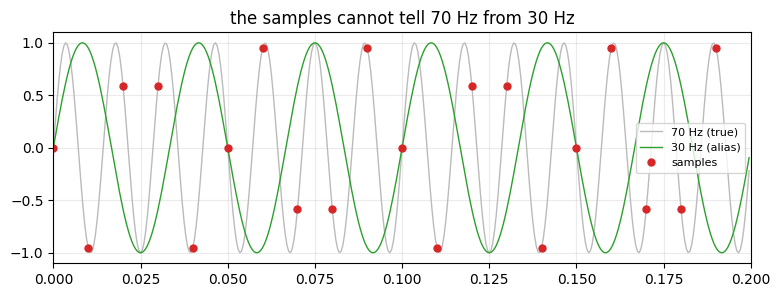

In [24]:
fs_a = 100.0
t_a = np.arange(0, 1.0, 1 / fs_a)
x_a = signals.sine(t_a, 70.0)
fr_a, amp_a = transforms.amplitude_spectrum(x_a, fs_a)
print(f"peak at {fr_a[np.argmax(amp_a)]:.1f} Hz  (input was 70 Hz, fs = 100 Hz)")

t_fine = np.arange(0, 0.2, 1 / 2000.0)
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t_fine, signals.sine(t_fine, 70.0), color="#bbb", lw=1, label="70 Hz (true)")
ax.plot(t_fine, signals.sine(t_fine, 30.0), color="#2ca02c", lw=1, label="30 Hz (alias)")
ax.plot(t_a[t_a < 0.2], x_a[t_a < 0.2], "o", color="#d62728", ms=5, label="samples")
ax.set_xlim(0, 0.2); ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax.set_title("the samples cannot tell 70 Hz from 30 Hz")
plt.show()

### 06-3 窓の比較

> Hann・Hamming・Blackman で漏れの裾と主葉幅を比べよ。

トレードオフは常に「主葉の幅 対 サイドローブの高さ」である。
Blackman は裾が最も低いが主葉が広く、近接した 2 つのトーンを分離できなくなる。

In [25]:
from scipy import signal as sps_w
n_w = 512
print(f"{'window':>10} {'main lobe (bins)':>18} {'peak sidelobe (dB)':>20}")
for name in ["boxcar", "hann", "hamming", "blackman"]:
    w = sps_w.get_window(name, n_w)
    W = np.abs(np.fft.rfft(w, 8192))
    W = W / W.max()
    db = 20 * np.log10(W + 1e-16)
    first_null = int(np.argmax(np.diff(db) > 0))
    side = float(db[first_null:].max())
    print(f"{name:>10} {first_null * n_w / 8192 * 2:18.2f} {side:20.1f}")

    window   main lobe (bins)   peak sidelobe (dB)
    boxcar               2.00                -13.3
      hann               4.00                -31.5
   hamming               4.00                -42.7
  blackman               6.00                -58.1


### 06-4 ゼロ詰め

> ゼロを足すと滑らかに見えるが分解能は上がらないことを示せ。

ゼロ詰めは DTFT を **細かく標本化し直す** だけで、新しい情報を足さない。
2 つのトーンを分離できるかは観測時間 $T$ が決めるので、
ゼロを足しても $1/T$ より細かい構造は現れない。

observation time 0.1s -> resolution 10 Hz; tones are 6 Hz apart

zero-pad × 1: 1 peak(s) in 180-230 Hz
zero-pad × 8: 3 peak(s) in 180-230 Hz
zero-pad ×64: 3 peak(s) in 180-230 Hz


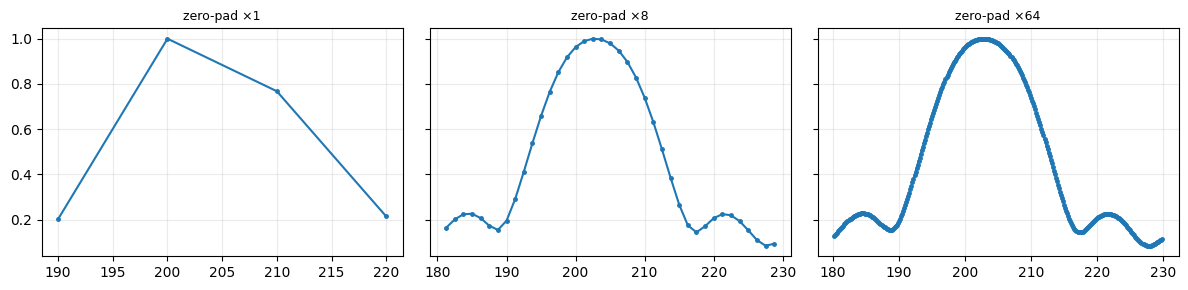


どれだけ詰めても山は 1 つのまま。分解能は観測時間で決まっている


In [26]:
fs_z = 1000.0
T_z = 0.1                                  # -> resolution 10 Hz
t_z = np.arange(0, T_z, 1 / fs_z)
x_z = signals.sine(t_z, 200.0) + signals.sine(t_z, 206.0)   # 6 Hz apart: unresolvable
print(f"observation time {T_z}s -> resolution {1 / T_z:.0f} Hz; tones are 6 Hz apart\n")
fig, ax = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for a_, pad in zip(ax, [1, 8, 64], strict=True):
    n_pad = int(x_z.size * pad)
    sp = np.abs(np.fft.rfft(x_z, n_pad))
    fr_z = np.fft.rfftfreq(n_pad, d=1 / fs_z)
    sel = (fr_z > 180) & (fr_z < 230)
    a_.plot(fr_z[sel], sp[sel] / sp.max(), "o-", ms=2.5)
    a_.set_title(f"zero-pad ×{pad}", fontsize=9); a_.grid(alpha=0.25)
    peaks = fr_z[sel][1:-1][(sp[sel][1:-1] > sp[sel][:-2]) & (sp[sel][1:-1] > sp[sel][2:])]
    print(f"zero-pad ×{pad:2d}: {len(peaks)} peak(s) in 180-230 Hz")
plt.tight_layout()
plt.show()
print("\nどれだけ詰めても山は 1 つのまま。分解能は観測時間で決まっている")

## 07 章 — 時間周波数解析

### 07-1 窓幅のトレードオフ

> `nperseg` を変えて時間分解能と周波数分解能が逆に動くことを示せ。

時間分解能は $\Delta t \approx N/f_s$、周波数分解能は $\Delta f \approx f_s/N$。
積は $\Delta t \cdot \Delta f \approx 1$ で、$N$ をどう選んでも改善しない。

In [27]:
fs_tf = 2000.0
t_tf = np.arange(0, 2.0, 1 / fs_tf)
x_tf = signals.chirp(t_tf, 50.0, 700.0)
print(f"{'nperseg':>9} {'Δt [ms]':>10} {'Δf [Hz]':>10} {'product':>9}")
for nps in [64, 256, 1024]:
    f_, tt_, S_ = transforms.stft(x_tf, fs_tf, nperseg=nps, noverlap=nps // 2)
    dt_res = nps / fs_tf * 1000
    df_res = fs_tf / nps
    print(f"{nps:9d} {dt_res:10.2f} {df_res:10.2f} {dt_res / 1000 * df_res:9.2f}")

  nperseg    Δt [ms]    Δf [Hz]   product
       64      32.00      31.25      1.00
      256     128.00       7.81      1.00
     1024     512.00       1.95      1.00


### 07-2 バースト検出

> CWT で 200 Hz バーストの中心時刻を推定し、STFT と比べよ。

In [28]:
def morlet_cwt2(x_sig, fs_w, freqs_w, f_c=1.0, n_sigma=6.0):
    out = np.empty((freqs_w.size, x_sig.size), dtype=complex)
    for i, f in enumerate(freqs_w):
        s = f_c / f
        half = int(n_sigma * s * fs_w / 2)
        tt = np.arange(-half, half + 1) / fs_w
        psi = np.pi**-0.25 * np.exp(2j * np.pi * f_c * tt / s) * np.exp(-(tt / s) ** 2 / 2)
        out[i] = np.convolve(x_sig, np.conj((psi / np.sqrt(s))[::-1]), mode="same") / fs_w
    return out

fs_b2 = 1000.0
t_b2 = np.arange(0, 2.0, 1 / fs_b2)
true_centre = 0.4
x_b2 = np.exp(-((t_b2 - true_centre) / 0.03) ** 2) * np.sin(2 * np.pi * 200 * t_b2)        + 0.3 * np.sin(2 * np.pi * 8 * t_b2)

fq = np.logspace(np.log10(120), np.log10(320), 30)
W2 = np.abs(morlet_cwt2(x_b2, fs_b2, fq))
cwt_centre = t_b2[np.unravel_index(np.argmax(W2), W2.shape)[1]]

f_s2, t_s2, S2 = transforms.stft(x_b2, fs_b2, nperseg=256, noverlap=192)
band = (f_s2 > 150) & (f_s2 < 250)
stft_centre = t_s2[int(np.argmax(np.abs(S2[band]).sum(axis=0)))]
print(f"true centre {true_centre:.3f} s")
print(f"CWT  estimate {cwt_centre:.3f} s   error {abs(cwt_centre - true_centre) * 1000:5.1f} ms")
print(f"STFT estimate {stft_centre:.3f} s   error {abs(stft_centre - true_centre) * 1000:5.1f} ms")

true centre 0.400 s
CWT  estimate 0.400 s   error   0.0 ms
STFT estimate 0.384 s   error  16.0 ms


### 07-3 COLA が破れる理由

矩形窓を 50% ずつ重ねると、重なり和は $1+1=2$ の区間と $1$ の区間が交互になり、
**定数にならない**。逆変換で振幅が周期的に脈打つ。
Hann 窓は $w(t)+w(t+N/2)=1$ を満たすので和が定数になる。

In [29]:
from scipy import signal as sps_c
nps = 256
for name in ["hann", "boxcar"]:
    w = sps_c.get_window(name, nps, fftbins=True)
    acc = np.zeros(nps * 6)
    for start in range(0, acc.size - nps, nps // 2):
        acc[start:start + nps] += w
    core = acc[nps:-nps]
    print(f"{name:>8}: overlap-add sum ranges [{core.min():.3f}, {core.max():.3f}]"
          f"  ripple {(core.max() - core.min()) / core.mean():.3f}")

    hann: overlap-add sum ranges [1.000, 1.000]  ripple 0.000
  boxcar: overlap-add sum ranges [2.000, 2.000]  ripple 0.000


### 07-4 中心周波数と Q

$f_c$ を上げると wavelet の振動回数が増え、包絡が同じでも **Q が上がる**。
周波数分解能は良くなるが、時間的な広がりが増えて過渡を追えなくなる。
不確定性の予算配分を変えているだけである。

In [30]:
fs_q = 1000.0
print(f"{'f_c':>6} {'Q at 40 Hz':>12} {'time support [ms]':>19}")
for f_c in [0.5, 1.0, 3.0]:
    f_target = 40.0
    s = f_c / f_target
    half = int(6 * s * fs_q / 2)
    tt = np.arange(-half, half + 1) / fs_q
    psi = np.pi**-0.25 * np.exp(2j * np.pi * f_c * tt / s) * np.exp(-(tt / s) ** 2 / 2)
    sp = np.abs(np.fft.fft(psi, n=8192))          # complex wavelet -> full FFT
    fr = np.fft.fftfreq(8192, d=1 / fs_q)
    pos = fr > 0
    above = fr[pos][sp[pos] >= sp[pos].max() / np.sqrt(2)]
    bw = float(above.max() - above.min())
    print(f"{f_c:6.1f} {f_target / bw:12.2f} {tt.size / fs_q * 1000:19.1f}")

   f_c   Q at 40 Hz   time support [ms]
   0.5         1.88                75.0
   1.0         3.77               151.0
   3.0        11.70               449.0


### 07-5 スペクトル漏れ

> 窓なしと Hann 窓で、非整数周期の正弦波の漏れを dB で比べよ。

矩形窓(窓なし)は端で信号が跳ぶので、その不連続が広帯域の漏れを生む。
Hann 窓は端で 0 に落ちるので跳びが無く、裾が急速に下がる。

In [31]:
from scipy import signal as sps_l
fs_l, N_l = 1000.0, 512
t_l = np.arange(N_l) / fs_l
x_l = np.sin(2 * np.pi * 100.5 * t_l)          # 100.5 Hz: not an integer number of bins
for name in ["boxcar", "hann"]:
    w = sps_l.get_window(name, N_l)
    sp = np.abs(np.fft.rfft(x_l * w))
    db = 20 * np.log10(sp / sp.max() + 1e-16)
    fr_l = np.fft.rfftfreq(N_l, d=1 / fs_l)
    far = np.abs(fr_l - 100.5) > 20
    print(f"{name:>8}: leakage 20 Hz away from the tone = {db[far].max():6.1f} dB")

  boxcar: leakage 20 Hz away from the tone =  -26.6 dB
    hann: leakage 20 Hz away from the tone =  -69.9 dB


## 08 章 — PDE とスペクトル法

### 08-1 単一モードの熱方程式

> $u_0=\sin(mx)$ の解が $e^{-\alpha m^2 t}\sin(mx)$ になることを確かめよ。

$\sin(mx)$ は $\partial_{xx}$ の固有関数で固有値 $-m^2$。
熱方程式は各モードについて $\dot{\hat u} = -\alpha m^2 \hat u$ になるので、
指数減衰する。**高いモードほど速く消える** ので、熱伝導は平滑化作用素である。

In [32]:
L_s, n_s2, alpha_s = 2 * np.pi, 512, 0.2
xs2 = np.linspace(0, L_s, n_s2, endpoint=False)
print(f"{'m':>3} {'t':>5} {'max error':>12} {'decay factor':>14}")
for m in [1, 3, 6]:
    u0_s = np.sin(m * xs2)
    for t_s in [0.5, 2.0]:
        u = spectral.solve_heat_spectral(u0_s, L_s, alpha_s, t_s)
        exact = np.exp(-alpha_s * m**2 * t_s) * np.sin(m * xs2)
        print(f"{m:3d} {t_s:5.1f} {np.max(np.abs(u - exact)):12.2e}"
              f" {np.exp(-alpha_s * m**2 * t_s):14.6f}")

  m     t    max error   decay factor
  1   0.5     5.83e-16       0.904837
  1   2.0     3.35e-16       0.670320
  3   0.5     1.17e-15       0.406570
  3   2.0     7.63e-17       0.027324
  6   0.5     2.71e-16       0.027324
  6   2.0     6.75e-17       0.000001


### 08-2 スペクトル微分の収束次数

> 誤差を $N$ に対して描き、差分法と比べよ。

滑らかで周期的な関数に対し、スペクトル微分の誤差は **指数的**($N$ の多項式より速く)に落ちる。
差分法は $O(h^2)$ などの多項式収束にとどまる。
片対数で直線になれば指数収束、両対数で直線なら多項式収束である。

     N     spectral   2nd-order FD
    16     1.76e-07       9.36e-02
    32     2.89e-15       2.58e-02
    64     1.09e-14       6.51e-03
   128     2.33e-14       1.63e-03
   256     5.75e-14       4.09e-04


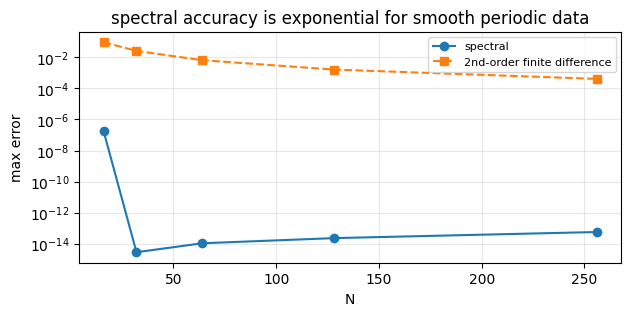

In [33]:
L_d = 2 * np.pi
print(f"{'N':>6} {'spectral':>12} {'2nd-order FD':>14}")
Ns, es, ef = [], [], []
for N_d in [16, 32, 64, 128, 256]:
    xd = np.linspace(0, L_d, N_d, endpoint=False)
    u = np.exp(np.sin(xd))
    exact = np.cos(xd) * u
    spec_err = float(np.max(np.abs(spectral.spectral_derivative(u, L_d, 1) - exact)))
    h = xd[1] - xd[0]
    fd = (np.roll(u, -1) - np.roll(u, 1)) / (2 * h)
    fd_err = float(np.max(np.abs(fd - exact)))
    Ns.append(N_d); es.append(spec_err); ef.append(fd_err)
    print(f"{N_d:6d} {spec_err:12.2e} {fd_err:14.2e}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(Ns, es, "o-", label="spectral")
ax.semilogy(Ns, ef, "s--", label="2nd-order finite difference")
ax.set_xlabel("N"); ax.set_ylabel("max error"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title("spectral accuracy is exponential for smooth periodic data")
plt.show()

### 08-3 定在波

> $u_0=\sin(2x)$、$v_0=0$ の波動解が $\cos(2ct)\sin(2x)$ になることを確認せよ。

波動方程式でも $\sin(2x)$ は固有関数で、時間側は $\ddot{\hat u} = -(2c)^2\hat u$。
初速 0 なので余弦解が選ばれる。節(node)が動かないので定在波になる。

In [34]:
L_w2, n_w2, c_w = 2 * np.pi, 512, 1.5
xw = np.linspace(0, L_w2, n_w2, endpoint=False)
u0_w = np.sin(2 * xw)
v0_w = np.zeros_like(xw)
for t_w2 in [0.3, 1.0, 2.5]:
    u = spectral.solve_wave_spectral(u0_w, v0_w, L_w2, c_w, t_w2)
    exact = np.cos(2 * c_w * t_w2) * np.sin(2 * xw)
    print(f"t = {t_w2:4.1f}   max error = {np.max(np.abs(u - exact)):.2e}"
          f"   amplitude = {np.cos(2 * c_w * t_w2):+.4f}")

t =  0.3   max error = 1.04e-15   amplitude = +0.6216
t =  1.0   max error = 1.36e-15   amplitude = -0.9900
t =  2.5   max error = 7.49e-16   amplitude = +0.3466


### 08-4 Poisson を解いて戻す

> $u''=f$ を解き、2 回微分して $f$ に戻るか確かめよ。

周期境界の Poisson は $\hat u_k = -\hat f_k / k^2$($k\ne0$)。
$k=0$ は決まらないので、$f$ の平均が 0 であることが可解条件になり、
解も定数分の不定性を持つ。

In [35]:
L_p, n_p = 2 * np.pi, 512
xp = np.linspace(0, L_p, n_p, endpoint=False)
f_p2 = np.sin(3 * xp) + 0.5 * np.cos(5 * xp)          # zero mean
u_p = spectral.solve_poisson_spectral(f_p2, L_p)
back = spectral.spectral_derivative(u_p, L_p, 2)
print(f"mean of f              = {f_p2.mean():.2e}  (solvability needs 0)")
print(f"max |u'' - f|          = {np.max(np.abs(back - f_p2)):.2e}")
print(f"analytic check: u = -sin(3x)/9 - cos(5x)/50 up to a constant")
analytic = -np.sin(3 * xp) / 9 - 0.5 * np.cos(5 * xp) / 25
print(f"max |u - analytic| after removing means = "
      f"{np.max(np.abs((u_p - u_p.mean()) - (analytic - analytic.mean()))):.2e}")

mean of f              = -2.78e-17  (solvability needs 0)
max |u'' - f|          = 1.26e-12
analytic check: u = -sin(3x)/9 - cos(5x)/50 up to a constant
max |u - analytic| after removing means = 3.40e-16


## 09 章 — 応用

### 09-1 2D の低周波と高周波

> 低周波だけ・高周波だけの再構成を作り、ぼけとエッジになる理由を述べよ。

2 次元でも話は同じである。低周波は緩やかな明暗(面)、高周波は急な変化(輪郭)を担う。
ローパスはエッジを消してぼかし、ハイパスは面を消して輪郭だけを残す。

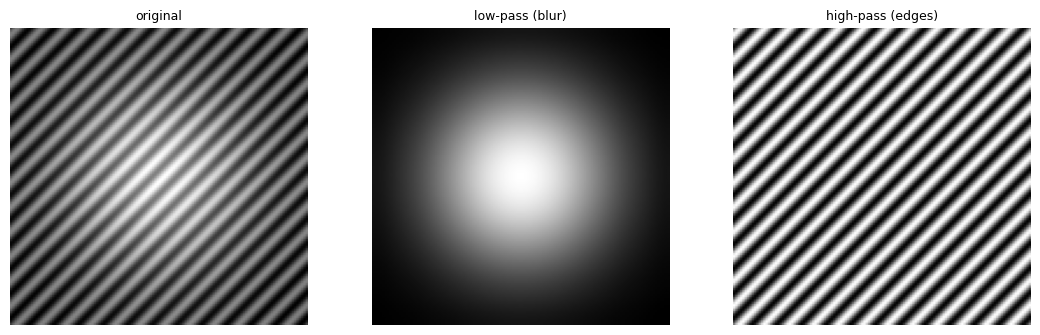

energy kept by low-pass :  84.5 %
energy kept by high-pass:  15.5 %


In [36]:
img = datasets.make_test_image(128)
F2 = np.fft.fftshift(np.fft.fft2(img))
ky, kx = np.meshgrid(np.fft.fftshift(np.fft.fftfreq(128)),
                     np.fft.fftshift(np.fft.fftfreq(128)), indexing="ij")
radius = np.hypot(kx, ky)
low = np.fft.ifft2(np.fft.ifftshift(F2 * (radius < 0.06))).real
high = np.fft.ifft2(np.fft.ifftshift(F2 * (radius >= 0.06))).real
fig, ax = plt.subplots(1, 3, figsize=(11, 3.4))
for a_, im, ttl in zip(ax, [img, low, high],
                       ["original", "low-pass (blur)", "high-pass (edges)"], strict=True):
    a_.imshow(im, cmap="gray"); a_.set_title(ttl, fontsize=9); a_.axis("off")
plt.tight_layout()
plt.show()
print(f"energy kept by low-pass : {np.sum(low**2) / np.sum(img**2) * 100:5.1f} %")
print(f"energy kept by high-pass: {np.sum(high**2) / np.sum(img**2) * 100:5.1f} %")

### 09-2 メル帯域数と再構成誤差

帯域を減らすほど圧縮率は上がるが、細かい周波数構造が失われる。
擬似逆行列でスペクトルを復元し、その誤差で測る。

In [37]:
def mel_fb(n_mels, n_fft, fs_m, fmin=50.0, fmax=3500.0):
    to_mel = lambda f: 2595.0 * np.log10(1.0 + f / 700.0)
    to_hz = lambda m: 700.0 * (10.0 ** (m / 2595.0) - 1.0)
    edges = to_hz(np.linspace(to_mel(fmin), to_mel(fmax), n_mels + 2))
    bins = np.floor((n_fft + 1) * edges / fs_m).astype(int)
    fb = np.zeros((n_mels, n_fft // 2 + 1))
    for i in range(n_mels):
        lo_, mid, hi_ = bins[i], bins[i + 1], bins[i + 2]
        if mid > lo_:
            fb[i, lo_:mid] = (np.arange(lo_, mid) - lo_) / (mid - lo_)
        if hi_ > mid:
            fb[i, mid:hi_] = (hi_ - np.arange(mid, hi_)) / (hi_ - mid)
    return fb

fs_m2 = 8000.0
t_m2 = np.arange(0, 1.0, 1 / fs_m2)
x_m2 = sum(np.sin(2 * np.pi * f * t_m2) for f in (220, 440, 880, 1760))
_, _, S_m2 = transforms.stft(x_m2, fs_m2, nperseg=512, noverlap=384)
P = np.abs(S_m2) ** 2
print(f"{'mel bands':>11} {'compression':>13} {'reconstruction rel.err':>24}")
for n_mels in [20, 40, 80]:
    fb = mel_fb(n_mels, 512, fs_m2)
    M = fb @ P
    back = np.linalg.pinv(fb) @ M
    err = float(np.linalg.norm(back - P) / np.linalg.norm(P))
    print(f"{n_mels:11d} {P.shape[0] / n_mels:12.1f}x {err:24.4f}")

  mel bands   compression   reconstruction rel.err
         20         12.8x                   0.8565
         40          6.4x                   0.5950
         80          3.2x                   0.2973


### 09-3 Fourier features のスケール

`scale` は使う最高周波数を決める。小さすぎると目的の高周波に届かず、
大きすぎると **ノイズまで当てはめる**(過学習)。
最適値は目的関数の帯域とノイズ水準で決まる。

In [38]:
rng_ff2 = np.random.default_rng(0)
xt2 = np.sort(rng_ff2.uniform(0, 1, 128))
target2 = lambda z: np.sin(2 * np.pi * 9 * z) + 0.4 * np.sin(2 * np.pi * 23 * z)
xq2 = np.linspace(0, 1, 1000)

def ff(z, m, scale):
    b = np.arange(1, m + 1) * scale / m
    ang = 2 * np.pi * np.outer(z, b)
    return np.column_stack([np.ones_like(z), np.cos(ang), np.sin(ang)])

print(f"{'scale':>7} {'clean RMSE':>12} {'noisy RMSE':>12}")
for scale in [4.0, 12.0, 32.0, 64.0]:
    row = []
    for noise in [0.0, 0.25]:
        yt2 = target2(xt2) + noise * rng_ff2.normal(size=xt2.size)
        A = ff(xt2, 16, scale)
        w, *_ = np.linalg.lstsq(A, yt2, rcond=None)
        row.append(float(np.sqrt(np.mean((ff(xq2, 16, scale) @ w - target2(xq2)) ** 2))))
    print(f"{scale:7.1f} {row[0]:12.4f} {row[1]:12.4f}")
print("\nノイズがあると大きすぎる scale が損をする")

  scale   clean RMSE   noisy RMSE
    4.0       0.4119       0.4298
   12.0       0.3085       0.3384
   32.0       0.8464       0.8491
   64.0       0.8775       0.9237

ノイズがあると大きすぎる scale が損をする


### 09-4 ウェルチの分解能

区間長 `nperseg` を伸ばすと分解能は上がるが、平均する区間数が減って分散が増える。
ピークの高さのばらつきと幅の両方で見ると、トレードオフがはっきりする。

In [39]:
from scipy import signal as sps_w2
rng_w = np.random.default_rng(3)
n_w2 = 4096
t_w3 = np.arange(n_w2)
print(f"{'nperseg':>9} {'segments':>10} {'peak sd over 20 runs':>22} {'half-width [bins]':>19}")
for nps in [64, 256, 1024]:
    peaks = []
    for r in range(20):
        rg = np.random.default_rng(100 + r)
        s = rg.normal(size=n_w2) + 0.6 * np.sin(2 * np.pi * 0.13 * t_w3)
        f_w4, P_w = sps_w2.welch(s, fs=1.0, nperseg=nps, noverlap=nps // 2)
        peaks.append(float(P_w.max()))
    f_w4, P_w = sps_w2.welch(rng_w.normal(size=n_w2) + 0.6 * np.sin(2 * np.pi * 0.13 * t_w3),
                             fs=1.0, nperseg=nps, noverlap=nps // 2)
    half = int(np.sum(P_w >= P_w.max() / 2))
    print(f"{nps:9d} {n_w2 // (nps // 2):10d} {np.std(peaks):22.4f} {half:19d}")

  nperseg   segments   peak sd over 20 runs   half-width [bins]
       64        128                 0.4860                   2
      256         32                 1.6617                   2


     1024          8                 8.0733                   1


### 09-5 サロゲートの必要性

白色ノイズを帰無仮説に置くと、AR(1) の有色ノイズは低周波にエネルギーが偏っているだけで
「有意なピーク」と判定されてしまう。位相ランダム化サロゲートは
**観測系列自身の振幅スペクトルを保つ** ので、この偏りを帰無分布に織り込む。

In [40]:
from scipy import signal as sps_s2

def peak_stat(x):
    _, P = sps_s2.welch(x, fs=1.0, nperseg=256, noverlap=128)
    return float(P[1:].max())

def ar1(n, phi, rng):
    e = np.zeros(n)
    for i in range(1, n):
        e[i] = phi * e[i - 1] + rng.normal()
    return e

n_trials = 60
white_reject = surrogate_reject = 0
rng_t = np.random.default_rng(7)
for _ in range(n_trials):
    series = ar1(1024, 0.7, rng_t)                   # pure noise: no periodicity
    obs = peak_stat(series)
    white_null = [peak_stat(rng_t.normal(size=1024)) for _ in range(40)]
    mags = np.abs(np.fft.rfft(series))
    sur_null = []
    for _ in range(40):
        ph = rng_t.uniform(0, 2 * np.pi, mags.size)
        ph[0] = 0.0
        sur_null.append(peak_stat(np.fft.irfft(mags * np.exp(1j * ph), n=1024)))
    white_reject += obs > np.quantile(white_null, 0.95)
    surrogate_reject += obs > np.quantile(sur_null, 0.95)
print(f"AR(1) noise, no real periodicity, {n_trials} trials, nominal 5 %:")
print(f"  white-noise null    -> false positives {white_reject / n_trials * 100:5.1f} %")
print(f"  phase-surrogate null-> false positives {surrogate_reject / n_trials * 100:5.1f} %")

AR(1) noise, no real periodicity, 60 trials, nominal 5 %:
  white-noise null    -> false positives 100.0 %
  phase-surrogate null-> false positives   6.7 %


---

以上で 01–09 章の演習 40 問の解答が終わりである。

繰り返し出てきたのは **「滑らかさ ↔ 減衰」と「時間 ↔ 周波数」の 2 つの対** である。
矩形波の $1/n$、三角波の $1/n^2$、rect の $1/\xi$、理想フィルタのリンギング、
ゼロ詰めで分解能が上がらないこと、CWT の定 Q — すべて同じ 1 つの構造の別の顔である。

09-5 は少し毛色が違う。ここでの誤りは変換の性質ではなく **帰無仮説の置き方** にある。
道具が正しくても、比較対象を間違えれば結論は間違う。